In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
from sklearn.datasets import load_wine

In [4]:
data = load_wine()

In [5]:
df=pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target

In [6]:
df.shape

(178, 14)

In [7]:
df["target"].value_counts()

target
1    71
0    59
2    48
Name: count, dtype: int64

In [8]:
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  targe

In [10]:
# ============================================================
# PREPROCESSING (SCALING)
# ============================================================

In [11]:
from sklearn.preprocessing import StandardScaler

X = df.drop('target', axis=1)
y = df['target']  # only for visualization later, not used in PCA fitting

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)
print(f"Mean (should be ~0): {X_scaled.mean():.4f}")
print(f"Std (should be ~1): {X_scaled.std():.4f}")

(178, 13)
Mean (should be ~0): 0.0000
Std (should be ~1): 1.0000


In [12]:
# ============================================================
# PCA FIT & EXPLAINED VARIANCE
# ============================================================

In [13]:
from sklearn.decomposition import PCA

In [14]:
# Fit PCA with all components first, to inspect variance distribution
pca_full = PCA()
pca_full.fit(X_scaled)

explained_var = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

for i, (ev, cv) in enumerate(zip(explained_var, cumulative_var), 1):
    print(f"PC{i}: {ev:.4f} ({ev*100:.1f}%) | Cumulative: {cv:.4f} ({cv*100:.1f}%)")

PC1: 0.3620 (36.2%) | Cumulative: 0.3620 (36.2%)
PC2: 0.1921 (19.2%) | Cumulative: 0.5541 (55.4%)
PC3: 0.1112 (11.1%) | Cumulative: 0.6653 (66.5%)
PC4: 0.0707 (7.1%) | Cumulative: 0.7360 (73.6%)
PC5: 0.0656 (6.6%) | Cumulative: 0.8016 (80.2%)
PC6: 0.0494 (4.9%) | Cumulative: 0.8510 (85.1%)
PC7: 0.0424 (4.2%) | Cumulative: 0.8934 (89.3%)
PC8: 0.0268 (2.7%) | Cumulative: 0.9202 (92.0%)
PC9: 0.0222 (2.2%) | Cumulative: 0.9424 (94.2%)
PC10: 0.0193 (1.9%) | Cumulative: 0.9617 (96.2%)
PC11: 0.0174 (1.7%) | Cumulative: 0.9791 (97.9%)
PC12: 0.0130 (1.3%) | Cumulative: 0.9920 (99.2%)
PC13: 0.0080 (0.8%) | Cumulative: 1.0000 (100.0%)


In [15]:
# ============================================================
# 2D VISUALIZATION
# ============================================================

PC1 + PC2 explained variance: 55.4%


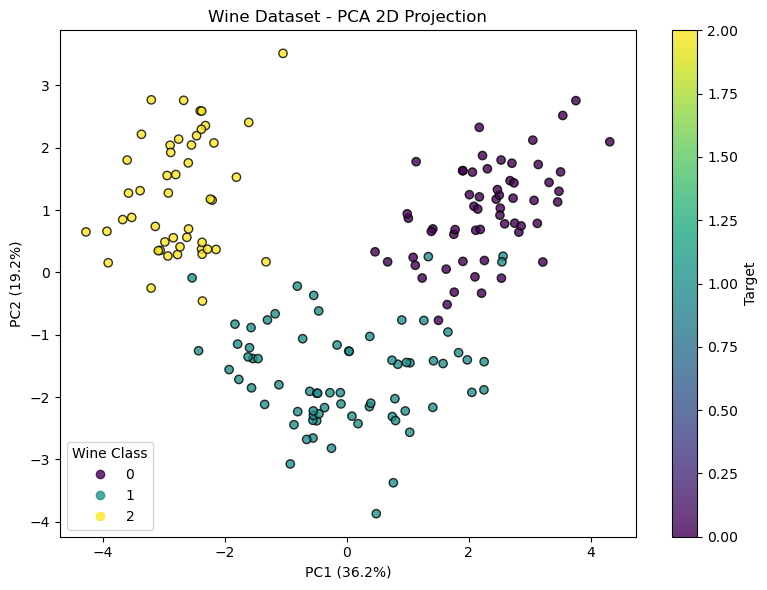

In [16]:
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

print(f"PC1 + PC2 explained variance: {pca_2d.explained_variance_ratio_.sum()*100:.1f}%")

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=y, cmap='viridis', edgecolor='k', alpha=0.8)
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('Wine Dataset - PCA 2D Projection')
plt.legend(*scatter.legend_elements(), title="Wine Class")
plt.colorbar(scatter, label='Target')
plt.tight_layout()
plt.show()

In [17]:
# ============================================================
# COMPONENT LOADINGS
# ============================================================

In [18]:
loadings = pd.DataFrame(
    pca_2d.components_.T,
    columns=['PC1', 'PC2'],
    index=X.columns
)
print(loadings.sort_values('PC1', ascending=False))

                                   PC1       PC2
flavanoids                    0.422934 -0.003360
total_phenols                 0.394661  0.065040
od280/od315_of_diluted_wines  0.376167 -0.164496
proanthocyanins               0.313429  0.039302
hue                           0.296715 -0.279235
proline                       0.286752  0.364903
alcohol                       0.144329  0.483652
magnesium                     0.141992  0.299634
ash                          -0.002051  0.316069
color_intensity              -0.088617  0.529996
alcalinity_of_ash            -0.239320 -0.010591
malic_acid                   -0.245188  0.224931
nonflavanoid_phenols         -0.298533  0.028779
